# Skope Field Camera Delay Calibration

This notebook does two things:
1. Generates a field-camera sync calibration sequence in the local pSeq framework.
2. Estimates scanner-to-Skope timing delay from prescan data using cross-correlation.

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path

import pypulseq as pp
from pSeq import pSeq_FieldCam_Calib
from skope_reader import Session
from twixtools import map_twix, read_twix
from scipy.signal import correlate

In [43]:
# Sequence design parameters (ported from fieldcam_calib.m).
TR = 500e-3
TRIG_DELAY = 1e-3
PRESCAN_DELAY = 1.0
CALIB_REP = 40
SCAN_REP = 10
ADC_DWELL = 1e-6
ADC_DURATION = 8e-3
SKOPE_DWELL = 3.584e-6
SEQ_VERSION = 'v0.1.0'

system = pp.Opts(
    max_grad=200,
    grad_unit='mT/m',
    max_slew=200,
    slew_unit='T/m/s',
    rf_ringdown_time=20e-6,
    rf_dead_time=100e-6,
    adc_dead_time=10e-6,
)

seq_fc = pSeq_FieldCam_Calib(
    system=system,
    tr=TR,
    trigger_delay=TRIG_DELAY,
    prescan_delay=PRESCAN_DELAY,
    calib_rep=CALIB_REP,
    scan_rep=SCAN_REP,
    adc_dwell=ADC_DWELL,
    adc_duration=ADC_DURATION,
    trigger_channel='ext1',
)

seq_fc.make_default_seq()
ok, timing_errors = seq_fc.check_timing(verbose=False)
if not ok:
    raise RuntimeError(f'Timing check failed: {timing_errors}')

seq_name = f'fieldcam_calib_cal{CALIB_REP}_scan{SCAN_REP}_{SEQ_VERSION}.seq'
seq_path = seq_fc.write_seq(seq_name=seq_name, out_dir='seq')
print('Wrote sequence:', seq_path)
print('Timing summary:', seq_fc.get_timing())

Prepared FieldCam calibration blocks:
  ADC samples: 8000
  ADC dwell: 1.000 us
  ADC duration: 8.000 ms
  Trigger delay: 1.000 ms
  Trigger channel: ext1
Wrote sequence: seq\fieldcam_calib_cal40_scan10_v0.1.0.seq
Timing summary: {'tr': 0.5, 'calib_rep': 40, 'scan_rep': 10, 'prescan_delay': 1.0, 'adc_samples': 8000, 'adc_dwell': np.float64(1e-06), 'adc_duration': 0.008, 'sequence_duration': 26.0}


In [40]:
def zscore(x):
    x = np.asarray(x, dtype=np.float64)
    std = np.std(x)
    if std == 0:
        return np.zeros_like(x)
    return (x - np.mean(x)) / std


def collapse_to_rep_ch_ro(arr):
    data = np.asarray(arr).squeeze()
    if data.ndim < 2:
        raise RuntimeError(f'Expected at least 2D twix data, got shape {data.shape}')

    if data.ndim == 2:
        data = data[np.newaxis, ...]

    if data.ndim > 3:
        rep = int(np.prod(data.shape[:-2]))
        data = data.reshape(rep, data.shape[-2], data.shape[-1])

    return data


def load_twix_magnitude_trace(path, n_rep=None):
    twix = map_twix(read_twix(str(path), parse_pmu=False))
    twix_last = twix[-1] if isinstance(twix, list) else twix
    if not isinstance(twix_last, dict) or 'image' not in twix_last:
        raise RuntimeError(f'TWIX image block not found: {path}')

    raw = collapse_to_rep_ch_ro(twix_last['image'][:])
    if n_rep is not None:
        raw = raw[:n_rep]

    mag_sos = np.sqrt((np.abs(raw) ** 2).sum(axis=(0, 1)))
    return zscore(mag_sos)


def load_skope_magnitude_trace(session, scan_id):
    scan = session.get_scan(scan_id, True)
    mag = np.asarray(scan.magnitude)
    if mag.ndim < 2:
        raise RuntimeError(f'Unexpected Skope magnitude shape for scan {scan_id}: {mag.shape}')

    axes_to_avg = tuple(range(mag.ndim - 1))
    mag_avg = np.mean(mag, axis=axes_to_avg)
    return zscore(mag_avg)


def estimate_delay(scanner_trace, skope_trace, dt_scanner, dt_skope, dt_interp):
    t_scanner = np.arange(scanner_trace.size) * dt_scanner
    t_skope = np.arange(skope_trace.size) * dt_skope

    t_end = min(t_scanner[-1], t_skope[-1])
    t_common = np.arange(0.0, t_end, dt_interp)

    scanner_i = np.interp(t_common, t_scanner, scanner_trace)
    skope_i = np.interp(t_common, t_skope, skope_trace)

    corr = correlate(scanner_i, skope_i, mode='full', method='fft')
    lags = np.arange(-len(skope_i) + 1, len(scanner_i))
    best = int(np.argmax(np.abs(corr)))
    delay = lags[best] * dt_interp

    return {
        'delay_s': float(delay),
        'lags_s': lags * dt_interp,
        'corr': corr,
        'scanner_interp': scanner_i,
        'skope_interp': skope_i,
        't_common': t_common,
    }

In [54]:
import skope_reader
skope_traj_path = 'skope_data/diffusion_eddy_spiral_20260419.h5'
calib_twix_path = 'scan_data/meas_MID00271_FID16431_fieldcam_calib_cal40_scan10_v0_1_0.dat'
session = Session(skope_traj_path)

skope_data = load_skope_magnitude_trace(session, scan_id=5)
twix_data = load_twix_magnitude_trace(calib_twix_path, n_rep=CALIB_REP)
print('Skope data shape:', skope_data.shape)
print('TWIX data shape:', twix_data.shape)



estimate_results = estimate_delay(
    scanner_trace=twix_data,
    skope_trace=skope_data,
    dt_scanner=ADC_DWELL,
    dt_skope=SKOPE_DWELL,
    dt_interp=5e-9,
)
print(f'Estimated delay: {estimate_results["delay_s"] * 1e6:.10f} us')

Software version: VD/VE (!?)

Scan  0


100%|██████████| 60.1M/60.1M [00:00<00:00, 131MB/s]


Scan  1


100%|██████████| 98.5M/98.5M [00:00<00:00, 3.12GB/s]


Skope data shape: (1675,)
TWIX data shape: (8000,)
Estimated delay: 120.4350000000 us


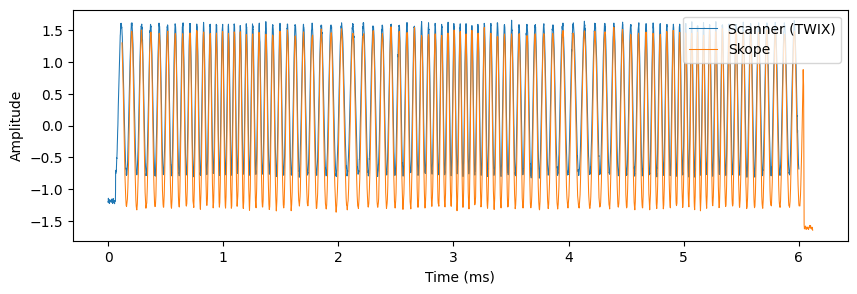

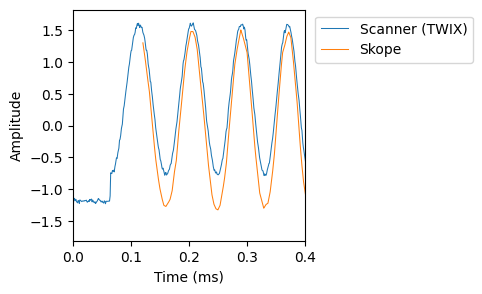

In [67]:
plt.figure(figsize=(10, 3))
plt.plot((estimate_results['t_common']) * 1e3, estimate_results['scanner_interp'], label='Scanner (TWIX)')
plt.plot((estimate_results['t_common'] + estimate_results['delay_s']) * 1e3, estimate_results['skope_interp'], label='Skope')
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude')
plt.legend(loc='upper right')
plt.show()

plt.figure(figsize=(3, 3))
plt.plot((estimate_results['t_common']) * 1e3, estimate_results['scanner_interp'], label='Scanner (TWIX)')
plt.plot((estimate_results['t_common'] + estimate_results['delay_s']) * 1e3, estimate_results['skope_interp'], label='Skope')
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude')
plt.xlim(0,0.4)
plt.legend(loc='upper right', bbox_to_anchor=(1.75, 1))
plt.show()


In [ ]:
delay_results = {}
summary_rows = []

for level in ['low', 'med', 'high']:
    res = estimate_delay(
        scanner_trace=scanner_traces[level],
        skope_trace=skope_traces[level],
        dt_scanner=dwell_adc,
        dt_skope=dwell_skope,
        dt_interp=interp_dt,
    )
    delay_results[level] = res

    summary_rows.append({
        'level': level,
        'delay_ms': 1e3 * res['delay_s'],
        'delay_us': 1e6 * res['delay_s'],
        'corr_peak_abs': float(np.max(np.abs(res['corr']))),
    })

summary_df = pd.DataFrame(summary_rows)
summary_df

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10), constrained_layout=True)

for row, level in enumerate(['low', 'med', 'high']):
    res = delay_results[level]

    ax0 = axes[row, 0]
    ax0.plot(res['t_common'] * 1e3, res['scanner_interp'], label='Scanner', lw=1.5)
    ax0.plot((res['t_common'] + res['delay_s']) * 1e3, res['skope_interp'], '--', label='Skope (shifted)', lw=1.2)
    ax0.set_title(f'{level.upper()} aligned traces')
    ax0.set_xlabel('Time (ms)')
    ax0.set_ylabel('Normalized magnitude')
    ax0.grid(alpha=0.3)
    ax0.legend(loc='upper right')

    ax1 = axes[row, 1]
    ax1.plot(res['lags_s'] * 1e3, res['corr'], lw=1.2)
    ax1.axvline(1e3 * res['delay_s'], color='r', linestyle='--', label=f"Delay: {1e6 * res['delay_s']:.2f} us")
    ax1.set_title(f'{level.upper()} cross-correlation')
    ax1.set_xlabel('Lag (ms)')
    ax1.set_ylabel('Correlation')
    ax1.grid(alpha=0.3)
    ax1.legend(loc='upper right')

plt.show()

In [ ]:
delay_mean_us = summary_df['delay_us'].mean()
delay_std_us = summary_df['delay_us'].std(ddof=1) if len(summary_df) > 1 else 0.0
print(f'Mean delay: {delay_mean_us:.3f} us')
print(f'Std delay: {delay_std_us:.3f} us')
summary_df